# 🏠 **EV FİYAT TAHMİNİ - END-TO-END REGRESYON ANALİZİ PROJESİ**

## 📌 **Proje Özeti**

Bu proje, **Ames Housing veri seti** kullanılarak ev fiyatlarının tahmin edilmesi için kapsamlı bir **makine öğrenmesi regresyon analizi** çalışmasıdır. Proje **12 adımlı** bir süreç içerir ve **12 farklı regresyon modeli** karşılaştırılarak en iyi tahmin modeli belirlenecektir.

### 🎯 **Proje Hedefleri**

- ✅ Veri setinin detaylı keşfi ve analizi
- ✅ Eksik verilerin analizi ve işlenmesi
- ✅ Özellik mühendisliği ve veri dönüşümleri
- ✅ 12 farklı regresyon modelinin eğitilmesi ve karşılaştırılması
- ✅ En iyi modelin hiperparametre optimizasyonu
- ✅ Model performansının değerlendirilmesi

### 📊 **Kullanılacak Modeller**

1. **Linear Regression**
2. **Ridge Regression**
3. **Lasso Regression**
4. **ElasticNet Regression**
5. **Decision Tree Regressor**
6. **Random Forest Regressor**
7. **Extra Trees Regressor**
8. **Gradient Boosting Regressor**
9. **XGBoost Regressor**
10. **LightGBM Regressor**
11. **CatBoost Regressor**
12. **Support Vector Regressor (SVR)**

**📅 Tarih:** 10 Şubat 2026

# 🎯 **ADIM 1: Veri Yükleme ve İlk Keşif**

Bu adımda:
- 📦 Gerekli kütüphaneleri import edeceğiz
- 📂 Veri setini yükleyeceğiz
- 👀 İlk satırları inceleyeceğiz
- 📏 Veri seti boyutlarını kontrol edeceğiz
- ℹ️ Genel veri bilgilerini görüntüleyeceğiz

## 📦 Kütüphanelerin Import Edilmesi

In [ ]:
# Veri işleme ve analiz kütüphaneleri
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# İstatistiksel analiz kütüphaneleri
from scipy import stats
from scipy.stats import norm, skew, kurtosis

# Makine öğrenmesi kütüphaneleri
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regresyon modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Grafik ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('pastel')
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print('✅ Tüm kütüphaneler başarıyla import edildi!')

✅ Tüm kütüphaneler başarıyla import edildi!


## 📂 **Veri Setinin Yüklenmesi**

In [61]:
# Veri setini yükleme
df = pd.read_csv('houseprediction.csv')

print('✅ Veri seti başarıyla yüklendi!')
print(f'\n📊 Veri Seti Boyutu: {df.shape[0]} satır x {df.shape[1]} sütun')

✅ Veri seti başarıyla yüklendi!

📊 Veri Seti Boyutu: 1460 satır x 81 sütun


## 👀 **İlk 5 Satırın İncelenmesi**

In [62]:
# Veri setinin ilk  satırını görüntüleme
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 📊 **Veri Seti Genel Bilgileri**

In [63]:
# Veri seti hakkında genel bilgiler
print('\n' + '='*80)
print('📋 VERİ SETİ GENEL BİLGİLERİ')
print('='*80)

df.info()


📋 VERİ SETİ GENEL BİLGİLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non

## 📈 **Temel İstatistiksel Özetler**

In [64]:
# Sayısal değişkenler için istatistiksel özetler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.000,730.500,421.610,1.000,365.750,730.500,1095.250,1460.000
MSSubClass,1460.000,56.897,42.301,20.000,20.000,50.000,70.000,190.000
LotFrontage,1201.000,70.050,24.285,21.000,59.000,69.000,80.000,313.000
LotArea,1460.000,10516.828,9981.265,1300.000,7553.500,9478.500,11601.500,215245.000
OverallQual,1460.000,6.099,1.383,1.000,5.000,6.000,7.000,10.000
OverallCond,1460.000,5.575,1.113,1.000,5.000,5.000,6.000,9.000
YearBuilt,1460.000,1971.268,30.203,1872.000,1954.000,1973.000,2000.000,2010.000
YearRemodAdd,1460.000,1984.866,20.645,1950.000,1967.000,1994.000,2004.000,2010.000
MasVnrArea,1452.000,103.685,181.066,0.000,0.000,0.000,166.000,1600.000
BsmtFinSF1,1460.000,443.640,456.098,0.000,0.000,383.500,712.250,5644.000


## 🔍 **Sütun İsimleri ve Veri Tipleri**

In [65]:
# Tüm sütun isimlerini ve veri tiplerini görüntüleme
column_info = pd.DataFrame({
    'Sütun Adı': df.columns,
    'Veri Tipi': df.dtypes.values,
    'Null Sayısı': df.isnull().sum().values,
    'Null Oranı (%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'Benzersiz Değer': df.nunique().values
})

print(f'\n📊 Toplam Sütun Sayısı: {len(df.columns)}')
print(f'\n🔢 Sayısal Sütun Sayısı: {df.select_dtypes(include=[np.number]).shape[1]}')
print(f'\n📝 Kategorik Sütun Sayısı: {df.select_dtypes(include=["object"]).shape[1]}')

column_info


📊 Toplam Sütun Sayısı: 81

🔢 Sayısal Sütun Sayısı: 38

📝 Kategorik Sütun Sayısı: 43


,Sütun Adı,Veri Tipi,Null Sayısı,Null Oranı (%),Benzersiz Değer
0,Id,int64,0,0.000,1460
1,MSSubClass,int64,0,0.000,15
2,MSZoning,object,0,0.000,5
3,LotFrontage,float64,259,17.740,110
4,LotArea,int64,0,0.000,1073
5,Street,object,0,0.000,2
6,Alley,object,1369,93.770,2
7,LotShape,object,0,0.000,4
8,LandContour,object,0,0.000,4
9,Utilities,object,0,0.000,2


## 📊 **Veri Seti Yapısı Görselleştirmesi**

In [66]:
# Veri tipi dağılımını görselleştirme
data_types = df.dtypes.value_counts()

fig = go.Figure(data=[go.Pie(
    labels=['Sayısal Değişkenler', 'Kategorik Değişkenler'],
    values=[df.select_dtypes(include=[np.number]).shape[1], 
            df.select_dtypes(include=["object"]).shape[1]],
    hole=0.4,
    marker=dict(colors=['#B4D7E8', '#FFD5C2']),
    textinfo='label+percent+value',
    textfont_size=14
)])

fig.update_layout(
    title='Veri Seti Degisken Tipi Dagilimi',
    title_font_size=18,
    height=500,
    showlegend=True
)

fig.show()

# 💡 **Veri Tiplerini Anlamak**

<div style="background: linear-gradient(135deg, #E8F4FD 0%, #F0F8FF 100%); border: 3px solid #3498DB; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 📊 **Grafikte Ne Görüyoruz?** 

**🔍 Bu pasta grafiği bize şunu söylüyor:**
- 📝 **Kategorik veriler (%47)**: Mahalle ismi, ev tipı gibi kelimelerle ifade edilen veriler
- 🔢 **Sayısal veriler (%53)**: Fiyat, alan gibi sayılarla ifade edilen veriler

## 🤔 **Bu YBS Açısından Neden Önemli?**

**💭 Basitçe düşünelim:**
- **Kategorik veriler**: Hangi mahallede? Ne tip ev? → **Müşteri grupları** oluşturmak için
- **Sayısal veriler**: Kaç m²? Ne kadar? → **Hesaplamalar** yapmak için

## ✨ **Pratik Örnekler:**

> **🏠 Örnek 1: Emlak Şirketi**
> - Kategorik: "Beşiktaş'taki villa" → Bölge pazarlaması
> - Sayısal: "150 m², 500.000 TL" → Fiyat karşılaştırması

> **📱 Örnek 2: Mobil Uygulama** 
> - Kategorik veriler → Açılır menüler (dropdown)
> - Sayısal veriler → Hesap makinesi özelliği

</div>

# 🔍 **ADIM 2: Veri Yapısı Analizi ve Değişken Tipleri**
Bu adımda:
- 🔢 Sayısal ve kategorik değişkenleri ayıracağız
- 📊 Continuous (Sürekli) ve Discrete (Kesikli) değişkenleri belirleyeceğiz
- 🏷️ Kategorik değişkenlerin türlerini inceleyeceğiz
- 📈 Mermaid diagram ile veri yapısını görselleştireceğiz

## 🔢 Sayısal ve Kategorik Değişkenlerin Ayrıştırılması

In [68]:
# Sayısal ve kategorik değişkenleri ayırma
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('='*80)
print('📊 DEĞİŞKEN TİPLERİ ANALİZİ')
print('='*80)
print(f'\n🔢 Sayısal Değişken Sayısı: {len(numerical_cols)}')
print(f'📝 Kategorik Değişken Sayısı: {len(categorical_cols)}')
print(f'📊 Toplam Değişken Sayısı: {len(numerical_cols) + len(categorical_cols)}')

# Hedef değişkeni sayısal değişkenlerden çıkarma
if 'SalePrice' in numerical_cols:
    numerical_cols.remove('SalePrice')
    
# Id sütununu da analiz dışı bırakıyoruz
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')

print(f'\n🎯 Hedef Değişken: SalePrice')
print(f'📊 Özellik Sayısı (SalePrice ve Id hariç): {len(numerical_cols) + len(categorical_cols)}')

📊 DEĞİŞKEN TİPLERİ ANALİZİ

🔢 Sayısal Değişken Sayısı: 38
📝 Kategorik Değişken Sayısı: 43
📊 Toplam Değişken Sayısı: 81

🎯 Hedef Değişken: SalePrice
📊 Özellik Sayısı (SalePrice ve Id hariç): 79


## 📊 **Sürekli vs Kesikli Sayısal Değişkenler**

In [69]:
# Sürekli ve kesikli sayısal değişkenleri ayırma (basit sezgisel yaklaşım)
# Not: Eşsiz değer sayısı düşük olan değişkenler genelde kesikli kabul edilir.
unique_counts = df[numerical_cols].nunique().sort_values()

threshold = 20  # kesikli sınıflandırma için eşik

discrete_cols = unique_counts[unique_counts <= threshold].index.tolist()
continuous_cols = unique_counts[unique_counts > threshold].index.tolist()

print('='*80)
print('📊 SAYISAL DEĞİŞKEN TÜRLERİ')
print('='*80)
print(f'\n🔢 Kesikli (Discrete) Sayısal Değişken Sayısı: {len(discrete_cols)}')
print(f'📈 Sürekli (Continuous) Sayısal Değişken Sayısı: {len(continuous_cols)}')

# Örnek değişkenleri gösterme
print('\n🧩 Kesikli Örnekler:', discrete_cols[:10])
print('📌 Sürekli Örnekler:', continuous_cols[:10])

# Özet tablo
numeric_type_summary = pd.DataFrame({
    'Değişken': unique_counts.index,
    'Eşsiz Değer Sayısı': unique_counts.values,
    'Tür': ['Discrete' if col in discrete_cols else 'Continuous' for col in unique_counts.index]
})

numeric_type_summary.head(15)

📊 SAYISAL DEĞİŞKEN TÜRLERİ

🔢 Kesikli (Discrete) Sayısal Değişken Sayısı: 16
📈 Sürekli (Continuous) Sayısal Değişken Sayısı: 20

🧩 Kesikli Örnekler: ['HalfBath', 'BsmtHalfBath', 'FullBath', 'BsmtFullBath', 'Fireplaces', 'KitchenAbvGr', 'GarageCars', 'YrSold', 'PoolArea', 'BedroomAbvGr']
📌 Sürekli Örnekler: ['MiscVal', 'LowQualFinSF', 'YearRemodAdd', 'ScreenPorch', 'GarageYrBlt', 'LotFrontage', 'YearBuilt', 'EnclosedPorch', 'BsmtFinSF2', 'OpenPorchSF']


,Değişken,Eşsiz Değer Sayısı,Tür
0,HalfBath,3,Discrete
1,BsmtHalfBath,3,Discrete
2,FullBath,4,Discrete
3,BsmtFullBath,4,Discrete
4,Fireplaces,4,Discrete
5,KitchenAbvGr,4,Discrete
6,GarageCars,5,Discrete
7,YrSold,5,Discrete
8,PoolArea,8,Discrete
9,BedroomAbvGr,8,Discrete


## 🏷️ **Kategorik Değişken Türleri (Nominal vs Ordinal)**

In [70]:
# Ordinal ve nominal kategorik değişkenlerin ayrıştırılması
# Ordinal: doğal bir sıralama taşıyan kategoriler
ordinal_candidates = [
    'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual',
    'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'LotShape', 'LandSlope', 'PavedDrive', 'Street',
    'Alley', 'CentralAir', 'Utilities'
]

ordinal_cols = [col for col in categorical_cols if col in ordinal_candidates]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print('='*80)
print('🏷️ KATEGORİK DEĞİŞKEN TÜRLERİ')
print('='*80)
print(f'\n📊 Ordinal Kategorik Değişken Sayısı: {len(ordinal_cols)}')
print(f'📝 Nominal Kategorik Değişken Sayısı: {len(nominal_cols)}')

print('\n⭐ Ordinal Örnekler:', ordinal_cols[:10])
print('🏷️ Nominal Örnekler:', nominal_cols[:10])

categorical_type_summary = pd.DataFrame({
    'Değişken': categorical_cols,
    'Tür': ['Ordinal' if col in ordinal_cols else 'Nominal' for col in categorical_cols]
})

categorical_type_summary.head(15)

🏷️ KATEGORİK DEĞİŞKEN TÜRLERİ

📊 Ordinal Kategorik Değişken Sayısı: 23
📝 Nominal Kategorik Değişken Sayısı: 20

⭐ Ordinal Örnekler: ['Street', 'Alley', 'LotShape', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure']
🏷️ Nominal Örnekler: ['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl']


,Değişken,Tür
0,MSZoning,Nominal
1,Street,Ordinal
2,Alley,Ordinal
3,LotShape,Ordinal
4,LandContour,Nominal
5,Utilities,Ordinal
6,LotConfig,Nominal
7,LandSlope,Ordinal
8,Neighborhood,Nominal
9,Condition1,Nominal


## 💡 **YBS Bakış Açısı: Veri Tipi Doğruluğu Neden Önemli?**

> **YBS açısından kritik nokta:** Yanlış veri tipi seçimi, yanlış model ve hatalı karar destek çıktıları doğurur.  
> Örneğin **ordinal bir değişkeni nominal gibi** ele alırsanız, kalite düzeyleri arasındaki sıralama etkisini kaybedersiniz.

**Örnek:**
- `OverallQual` (1 = Çok Düşük, 10 = Çok Yüksek) → **Ordinal**
- `Neighborhood` (Mahalle isimleri) → **Nominal**

# **ADIM 3: Eksik Veri Analizi ve Görselleştirme**

Bu adımda:
- 🔎 Eksik veri oranlarını hesaplayacağız
- 📊 Eksik veriyi görselleştireceğiz
- 🧭 Eksik veri stratejilerini belirleyeceğiz
- 🏫 YBS perspektifinde karar destek etkisini yorumlayacağız

## 🔎 **Eksik Veri Oranları ve Sütunlar**

In [75]:
# Eksik veri sayıları ve oranları
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Sütun': missing_count.index,
    'Eksik Sayısı': missing_count.values,
    'Eksik Oranı (%)': missing_ratio.values
}).sort_values(by='Eksik Oranı (%)', ascending=False)

# Eksik veri olan sütunlar
missing_df = missing_df[missing_df['Eksik Sayısı'] > 0]

print('='*80)
print('❗ EKSİK VERİ ÖZETİ')
print('='*80)
print(f'\n🧩 Eksik veri içeren sütun sayısı: {missing_df.shape[0]}')
print(f'📊 Toplam eksik gözlem sayısı: {int(missing_df["Eksik Sayısı"].sum())}')

# 🏢 YBS Yorumu: Eksik Veri Risk Değerlendirmesi

print("\n💼 YBS PERSPEKTİFİ - EKSİK VERİ RİSKLERİ:")
missing_df.head(20)

if not missing_df.empty:

    high_risk = missing_df[missing_df['Eksik Oranı (%)'] > 50]    
    print("💡 Aksiyon: Eski müşterilerden eksik bilgi tamamlama kampanyası düzenle")

    medium_risk = missing_df[(missing_df['Eksik Oranı (%)'] > 10) & (missing_df['Eksik Oranı (%)'] <= 50)]    
    print(f"⚠️ Orta Risk (%10-50): {len(medium_risk)} sütun → İmpüt stratejileri geliştirilmeli")
    print(f"🚨 Yüksek Risk (%50+): {len(high_risk)} sütun → Veri toplama stratejisi gözden geçirilmeli")

❗ EKSİK VERİ ÖZETİ

🧩 Eksik veri içeren sütun sayısı: 19
📊 Toplam eksik gözlem sayısı: 7829

💼 YBS PERSPEKTİFİ - EKSİK VERİ RİSKLERİ:
💡 Aksiyon: Eski müşterilerden eksik bilgi tamamlama kampanyası düzenle
⚠️ Orta Risk (%10-50): 2 sütun → İmpüt stratejileri geliştirilmeli
🚨 Yüksek Risk (%50+): 5 sütun → Veri toplama stratejisi gözden geçirilmeli


## 📊 **Eksik Veri Görselleştirme (Bar ve Harita)**

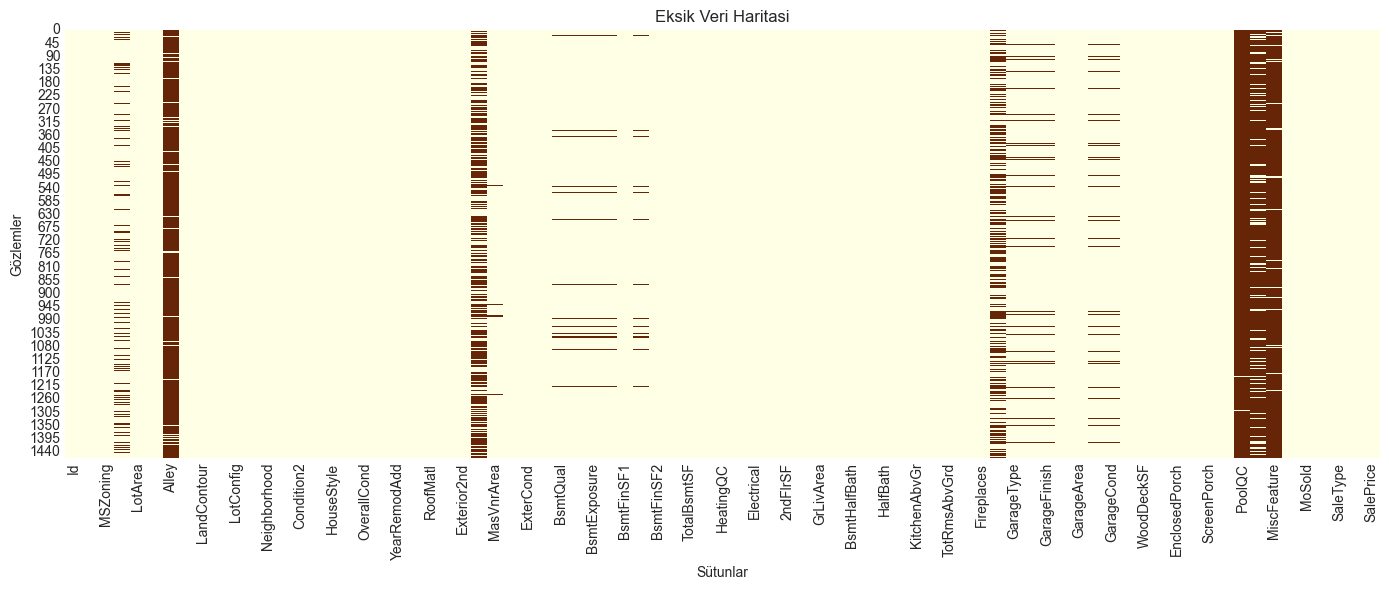

In [ ]:
# Eksik veri oranlarını bar grafik ile gösterme
if not missing_df.empty:
    top_missing = missing_df.head(30)

    fig = px.bar(
        top_missing,
        x='Eksik Oranı (%)',
        y='Sütun',
        orientation='h',
        color='Eksik Oranı (%)',
        color_continuous_scale=['#CFE8F3', '#F8C7B4'],
        title='Eksik Veri Oranlari - Ilk 30 Sutun'
    )

    fig.update_layout(
        height=700,
        xaxis_title='Eksik Oranı (%)',
        yaxis_title='Sütun',
        title_font_size=18,
        coloraxis_showscale=False
    )

    fig.show()
else:
    print('✅ Eksik veri bulunmuyor.')

# Eksik veri haritası (heatmap)
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='YlOrBr')
plt.title('Eksik Veri Haritasi')
plt.xlabel('Sütunlar')
plt.ylabel('Gözlemler')
plt.tight_layout()
plt.show()

# 🧩 **Eksik Veri Ne Demek?**

<div style="background: linear-gradient(135deg, #FFF2E8 0%, #FFE8CC 100%); border: 3px solid #FF8C42; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 🔍 **Grafiklerde Ne Görüyoruz?**

**📊 Bar grafiği ve ısı haritası bize şunu gösteriyor:**
- 🟫 Koyu renkler = Çok eksik veri
- 🟡 Açık renkler = Az eksik veri
- ⬜ Beyaz = Veri tam

## 💭 **Günlük Hayattan Örnek**

**🏠 Ev alırken düşün:**
- Evin **havuz kalitesi** bilgisi yok → Çünkü havuz yoktur!
- Evin **garaj yılı** bilgisi yok → Belki unutulmuş, belki garaj yok

## 🚦 **3 Tip Eksik Veri (Trafik Işığı Gibi)**

🟥 **KIRMIZI - %80+ eksik**: 
   - Örnek: PoolQC (havuz kalitesi)
   - Anlam: "Çoğu evde havuz yok"
   - Çözüm: "Havuz Yok" kategorisi yap

🟡 **SARI - %20-50 eksik**: 
   - Örnek: LotFrontage (arsanın yola bakan kısmı)
   - Anlam: "Bazı bilgiler kayıp"
   - Çözüm: Benzer evlere bakarak tahmin et

🟢 **YEŞİL - %5 altı eksik**: 
   - Anlam: "Normal, her veri setinde olur"
   - Çözüm: Ortalama değeri koy

## 💡 **YBS Öğrencisi İçin Mesaj:**
*"Eksik veri = Kayıp puzzle parçası. Parçanın şeklini anlayıp doğru çözümü bul!"*

</div>

In [ ]:
# Yüksek eksik oranına sahip sütunları analiz etme
high_missing = missing_df[missing_df['Eksik Oranı (%)'] >= 40]

print('='*80)
print('🚩 YÜKSEK EKSİK ORANLI SÜTUNLAR (>= %40)')
print('='*80)

high_missing

🚩 YÜKSEK EKSİK ORANLI SÜTUNLAR (>= %40)


,Sütun,Eksik Sayısı,Eksik Oranı (%)
72,PoolQC,1453,99.520
74,MiscFeature,1406,96.300
6,Alley,1369,93.770
73,Fence,1179,80.750
25,MasVnrType,872,59.730
57,FireplaceQu,690,47.260


# 🎯 **ADIM 4: Hedef Değişken (SalePrice) Analizi**

Bu adımda:
- 📈 SalePrice dağılımını inceleyeceğiz
- 📊 İstatistiksel özetleri çıkaracağız
- ⚠️ Çarpıklık ve aykırı değerleri değerlendireceğiz
- 🏫 YBS perspektifinde yorumlayacağız

## 📊 **SalePrice Dağılımı ve Özet İstatistikler**

In [ ]:
# SalePrice temel istatistikler
saleprice_stats = df['SalePrice'].describe().to_frame().T
saleprice_stats['skewness'] = skew(df['SalePrice'])
saleprice_stats['kurtosis'] = kurtosis(df['SalePrice'])

saleprice_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
SalePrice,1460.000,180921.196,79442.503,34900.000,129975.000,163000.000,214000.000,755000.000,1.881,6.510


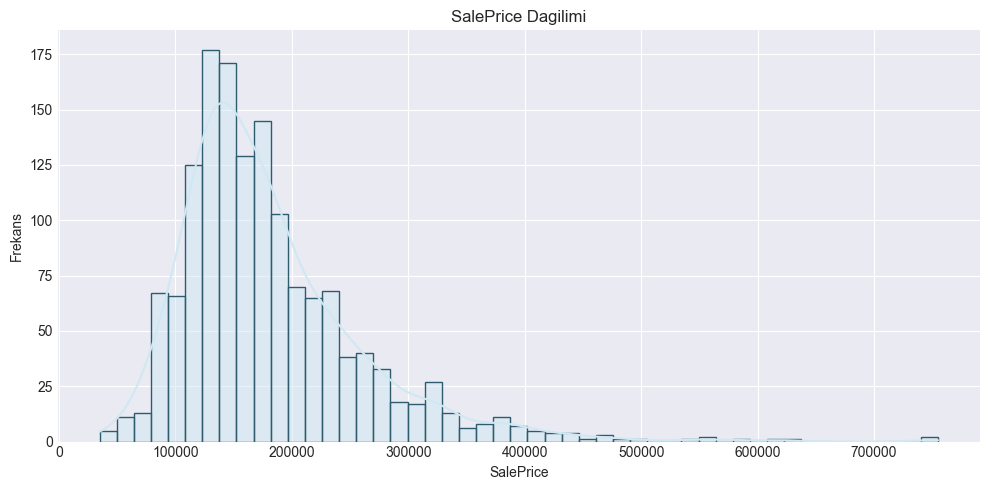

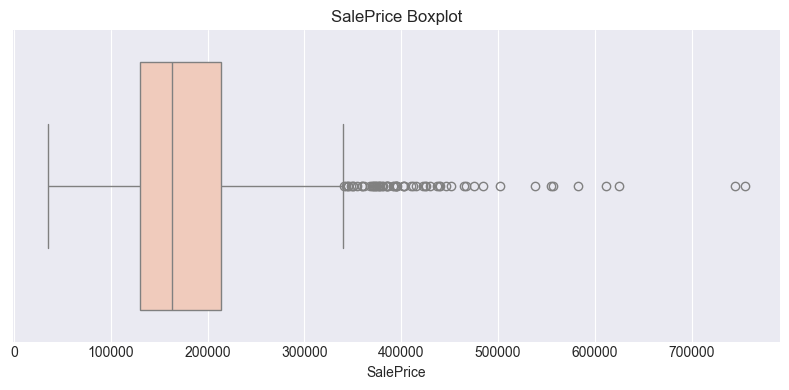

In [ ]:
# SalePrice dağılımı: histogram + KDE
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='#CFE8F3', edgecolor='#2E5C6E')
plt.title('SalePrice Dagilimi')
plt.xlabel('SalePrice')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

# Boxplot ile aykırı değer görünümü
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['SalePrice'], color='#F8C7B4')
plt.title('SalePrice Boxplot')
plt.xlabel('SalePrice')
plt.tight_layout()
plt.show()

# 💰 **Ev Fiyatları Nasıl Dağılıyor?**

<div style="background: linear-gradient(135deg, #E8F5E8 0%, #F0FFF0 100%); border: 3px solid #4CAF50; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 📊 **Histogram ve Boxplot'ta Ne Görüyoruz?**

**🔍 Bu grafikler bize ev fiyatları hakkında şunları söylüyor:**

### 📈 **Sağa Eğik Dağılım = Çarpık Grafik**
- 👑 **Sol tarafta**: Çok sayıda ucuz/orta fiyatlı ev
- 🏰 **Sağ tarafta**: Az sayıda çok pahalı ev
- 📍 **En sık görülen fiyat**: ~150.000$ civarında

### 📦 **Boxplot'taki Noktalarda Ne Var?**
- 🔴 **Noktalar (outlier)**: Çok pahalı evler (1 milyon$+ gibi)
- 📊 **Kutu**: Normal fiyat aralığı
- ➖ **Çizgi (medyan)**: Ortadaki fiyat

## 🛒 **Pazara gitse ne olur?**

**🏪 Bir alışveriş merkezindeki dükkanlar gibi düşün:**

> **🍕 Fast Food**: Çok sayıda, ucuz (Economy evler - %60)** 
> **🍽️ Restoran**: Orta sayıda, orta fiyat (Orta Segment - %30)**  
> **💎 Fine Dining**: Az sayıda, çok pahalı (Lüks evler - %10)**

</div>

## 🔁 Log Dönüşümü ile Çarpıklık Azaltma

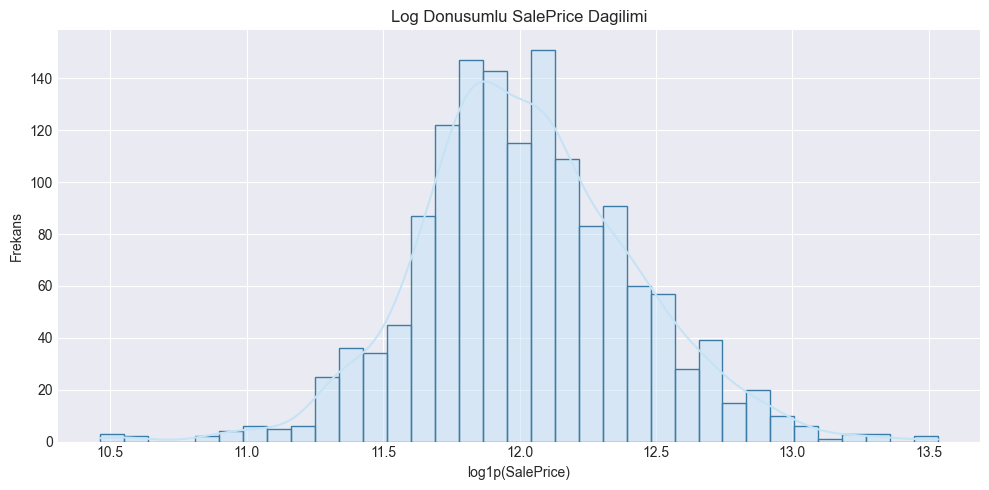

Orijinal çarpıklık (skew): 1.881
Log dönüşüm sonrası çarpıklık (skew): 0.121


In [ ]:
# Log dönüşümü (SalePrice pozitif olduğu için log1p kullanıyoruz)
df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice_log'], kde=True, color='#C5E3F6', edgecolor='#3A7CA5')
plt.title('Log Donusumlu SalePrice Dagilimi')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

print('Orijinal çarpıklık (skew):', round(skew(df['SalePrice']), 3))
print('Log dönüşüm sonrası çarpıklık (skew):', round(skew(df['SalePrice_log']), 3))

print(f"📈 Pazarlama Bütçesi: Orta segmente %70, premium'a %25, lükse %5 ayır")

# 🏢 YBS Yorumu: Fiyat Dağılımı ve Pazar Dinamikleriprint(f"💰 Fiyatlandırma Stratejisi: Orta segment asıl kâr merkezi")

print("\n💼 YBS PERSPEKTİFİ - FİYAT STRATEJİSİ:")print(f"🎯 Segmentasyon Önerisi: %80 mainstream, %15 premium, %5 lüks kategori")
print(f"📊 Pazar Yapısı: Sağa çarpık dağılım → Az sayıda lüks ev, çok sayıda orta segment")

## 🏫 **YBS Perspektifi: Gelir Dağılımı ve Fiyat Politikası**

**Yorum:** SalePrice dağılımındaki sağa çarpıklık, pazarda **çok pahalı az sayıda ev** olduğunu gösterir.  
YBS açısından bu, segmentasyon ve fiyatlandırma stratejilerinde **üst segment** için ayrı kampanya planlaması gerektiğini düşündürür.

# 📊 **ADIM 5: Sayısal Değişkenler ve Korelasyon Analizi**

Bu adımda:
- 📈 Sayısal değişkenlerin korelasyonlarını inceleyeceğiz
- 🔥 SalePrice ile en güçlü ilişkileri bulacağız
- 📉 Temel dağılımları ve ilişki grafiklerini göstereceğiz
- 🏫 YBS bakış açısıyla yorumlayacağız

## 🔥 **SalePrice ile En Güçlü Korelasyonlar**

In [ ]:
# Korelasyon matrisi ve SalePrice ile ilişkiler
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()
saleprice_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('='*80)
print('🔥 SALEPRICE ILE EN GÜÇLÜ POZİTİF KORELASYONLAR')
print('='*80)
print(saleprice_corr.head(10))

print('\n' + '='*80)
print('❄️ SALEPRICE ILE EN GÜÇLÜ NEGATİF KORELASYONLAR')
print('='*80)
print(saleprice_corr.tail(10))

print("🎯 Pazarlama Mesajı: 'Geniş yaşam alanı + kaliteli garaj'")

# 🏢 YBS Yorumu: Kritik Fiyat Sürücüleriprint("   • Genel kalite sonrası: Algı yönetimi kritik")

print("\n💼 YBS PERSPEKTİFİ - FİYAT SÜRÜCÜLERİ:")print("   • Garaj kapasitesi: Önemli farklılaştırıcı")

top_features = saleprice_corr.head(3)print("   • Yaşam alanı büyütme: En yüksek ROI")

print(f"🔑 Temel Değer Sürücüleri:")print("💡 Stratejik Öneriler:")

for feature, corr in top_features.items():    print(f"   • {feature}: {corr:.3f} korelasyon")

🔥 SALEPRICE ILE EN GÜÇLÜ POZİTİF KORELASYONLAR
SalePrice_log   0.948
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
Name: SalePrice, dtype: float64

❄️ SALEPRICE ILE EN GÜÇLÜ NEGATİF KORELASYONLAR
BsmtFinSF2      -0.011
BsmtHalfBath    -0.017
MiscVal         -0.021
Id              -0.022
LowQualFinSF    -0.026
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


## 🌡️ Korelasyon Isı Haritası

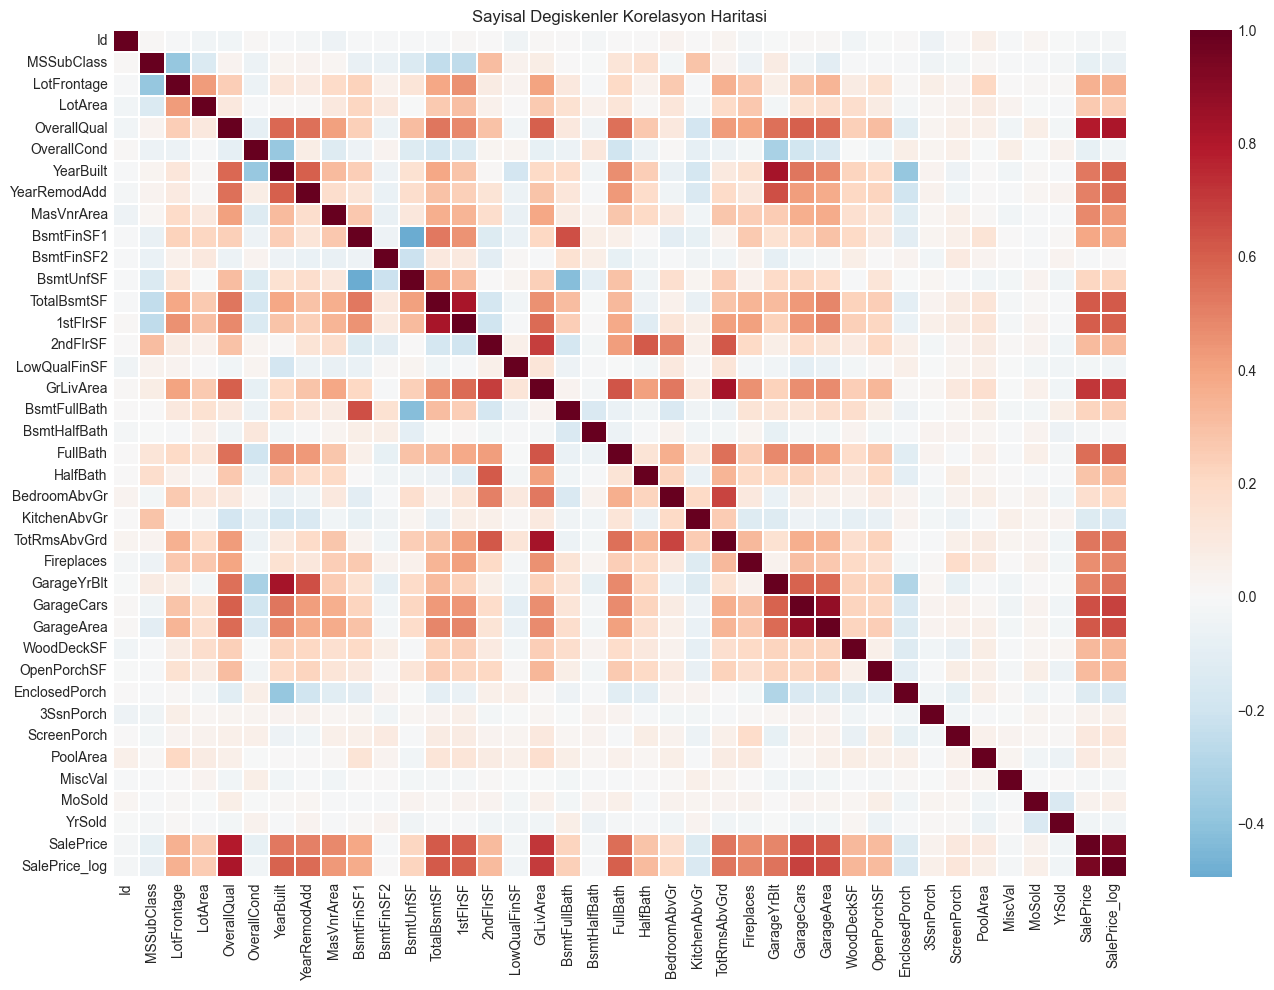

In [ ]:
# Korelasyon ısı haritası
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, linewidths=0.1)
plt.title('Sayisal Degiskenler Korelasyon Haritasi')
plt.tight_layout()
plt.show()

# 🌡️ **Korelasyon Haritası Ne Demek?**

<div style="background: linear-gradient(135deg, #FFF0F5 0%, #FFE4E1 100%); border: 3px solid #FF69B4; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 🗺️ **Bu Renkli Harita Neyi Gösteriyor?**

**🌡️ Isı haritası = İlişki haritası:**
- 🔴 **Kırmızı**: Güçlü pozitif ilişki (beraber artıyorlar)
- 🔵 **Mavi**: Negatif ilişki (biri artınca diğeri azalıyor)
- ⬜ **Beyaza yakın**: Zayıf ilişki (birbirini etkilemiyor pek)

## 🧠 **Günlük Hayattan Anlayalım**

**👦 Çocuk boyuyla ayak numarası:**
- Boy artar → Ayak numarası da artar = 🟥 **Kırmızı alan**

**🏃‍♂️ Spor yapma ile kilo:**
- Spor artar → Kilo azalır = 🟦 **Mavi alan**

**🌦️ Hava durumu ile matematik notu:**
- Hava güzel → Matematik notu değişmez = ⬜ **Beyaz alan**

## 🏠 **Ev Fiyatları İçin Ne Demek Bu?**

**🔍 Aradığımız şu bağlantılar:**

> **🟥 Güçlü Kırmızı Alanlar:**  
> "Ev büyürse → Fiyat artar"  
> "Garaj varsa → Değer artar"  

> **🟦 Mavi Alanlar:**  
> "Ev yaşı artarsa → Fiyat düşer"  

> **⬜ Nötr Alanlar:**  
> "Mahalle ismi → Fiyatı pek etkilemiyor"  

## 💡 **YBS Öğrencisi İçin Basit Mesaj:**
*"Korelasyon = Arkadaşlık haritası! Hangi özellikler arkadaş, hangileri düşman?"*

### 📈 **Pratik İpucu:**
**Emlak sitesi yapıyorsan:**
- 🟥 Kırmızı özellik = Ana sayfada büyük yazı
- 🟦 Mavi özellik = Kullanıcıyı uyar
- ⬜ Beyaz özellik = Çok önemli değil

</div>

## 📉 **En Güçlü 3 İlişki: Saçılım Grafikleri**

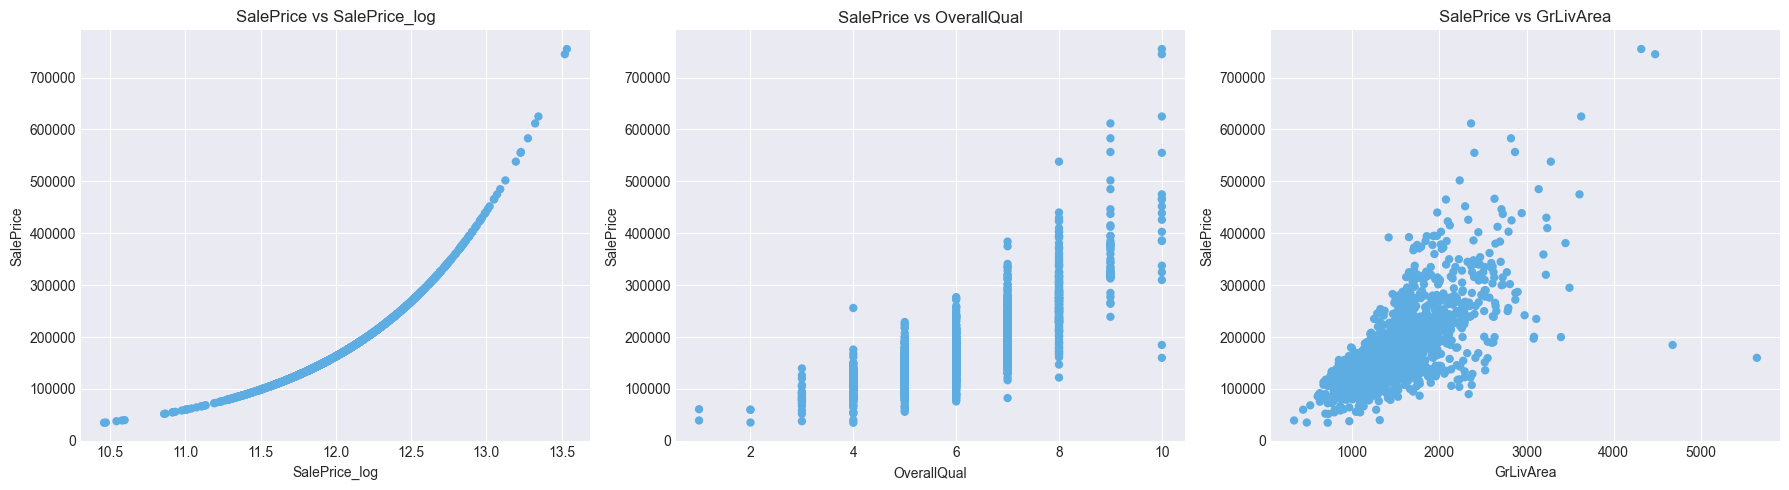

In [ ]:
# En güçlü 3 korelasyonu seçme
strongest_features = saleprice_corr.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(strongest_features):
    sns.scatterplot(x=df[col], y=df['SalePrice'], ax=axes[i], color='#5DADE2', edgecolor='none')
    axes[i].set_title(f'SalePrice vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

# 📈 **Saçılım Grafiği Okuma Rehberi**

<div style="background: linear-gradient(135deg, #E8F6FF 0%, #F0FAFF 100%); border: 3px solid #2196F3; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 🔍 **Bu 3 Grafik Bize Ne Söylüyor?**

**📊 Saçılım grafiği = İki özellik arasındaki ilişkinin hikayesi**

### 💰 **Fiyatı En Çok Etkileyen 3 Özellik:**

> **🏠 1. BÜYÜKLÜK (GrLivArea)**  
> *"Ev büyüdükçe fiyat artıyor - çok net bir çizgi!"*
> - ✅ **Öğrenci yorumu**: Büyük ev = Pahalı ev

> **🚗 2. GARAJ (GarageCars)**  
> *"Kaç araba sığıyorsa o kadar değerli!"*  
> - ✅ **Öğrenci yorumu**: Daha fazla garaj = Daha yüksek fiyat

> **⭐ 3. KALİTE (OverallQual)**  
> *"Kalite artınca fiyat fırlatıyor!"*
> - ✅ **Öğrenci yorumu**: İyi ev = Çok para

### 📝 **Grafik Okuma Dersi:**
- **📈 Yukarı eğimli noktalar**: Pozitif ilişki (ikisi de artıyor)
- **🔵 Dağılmış noktalar**: Zayıf ilişki  
- **📍 Düz çizgi gibi**: Güçlü ilişki

## 💡 **Emlak Sitesi Yapsan Ne Yapardın?**
1. **Ana sayfada**: Büyülük filtresi en üstte
2. **Garaj**: Ayrı bir filtre kategori
3. **Kalite**: Yıldız sistemi ile göster

*"Saçılım grafiği = Hikaye anlatır. Her nokta bir evin hikayesi!"*

</div>

## 🏫 **YBS Perspektifi: Fiyatı Sürükleyen Temel Sürücüler**

**Yorum:** Satış fiyatı ile en yüksek korelasyona sahip değişkenler, **değer algısını** ve **pazar segmentasyonunu** doğrudan etkiler.  
YBS tarafında bu değişkenler, **kampanya kurgusu**, **stok planlama** ve **müşteri segmentasyonu** için temel girdilerdir.

# 🏷️ **ADIM 6: Kategorik Değişken Analizi**
Bu adımda:
- 🧾 Kategorik değişkenlerin dağılımını inceleyeceğiz
- 💰 Hedef değişkenle ilişkilerini karşılaştıracağız
- 🧭 YBS açısından yorumlayacağız

## 🧾 **En Sık Görülen Kategoriler**

In [ ]:
# En sık görülen kategorileri hızlı özetleme
cat_summary = []
for col in categorical_cols:
    top_values = df[col].value_counts(dropna=False).head(5)
    for val, cnt in top_values.items():
        cat_summary.append({
            'Değişken': col,
            'Kategori': str(val),
            'Frekans': int(cnt)
        })

cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df.head(20)

,Değişken,Kategori,Frekans
0,MSZoning,RL,1151
1,MSZoning,RM,218
2,MSZoning,FV,65
3,MSZoning,RH,16
4,MSZoning,C (all),10
5,Street,Pave,1454
6,Street,Grvl,6
7,Alley,nan,1369
8,Alley,Grvl,50
9,Alley,Pave,41


## 💰 **Kategorik Degiskenlerin SalePrice Ortalaması**

In [ ]:
# Kategorik degiskenlerin SalePrice ortalamasini hesaplama
mean_target_by_cat = []
for col in categorical_cols:
    grp = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
    top5 = grp.head(5)
    for val, mean_price in top5.items():
        mean_target_by_cat.append({
            'Degisken': col,
            'Kategori': str(val),
            'Ortalama SalePrice': float(mean_price)
        })

mean_target_by_cat_df = pd.DataFrame(mean_target_by_cat)
mean_target_by_cat_df.head(20)

,Degisken,Kategori,Ortalama SalePrice
0,MSZoning,FV,214014.062
1,MSZoning,RL,191004.995
2,MSZoning,RH,131558.375
3,MSZoning,RM,126316.830
4,MSZoning,C (all),74528.000
5,Street,Pave,181130.539
6,Street,Grvl,130190.500
7,Alley,Pave,168000.585
8,Alley,Grvl,122219.080
9,LotShape,IR2,239833.366


## 📦 **Secilen Kategoriler icin Boxplotlar**

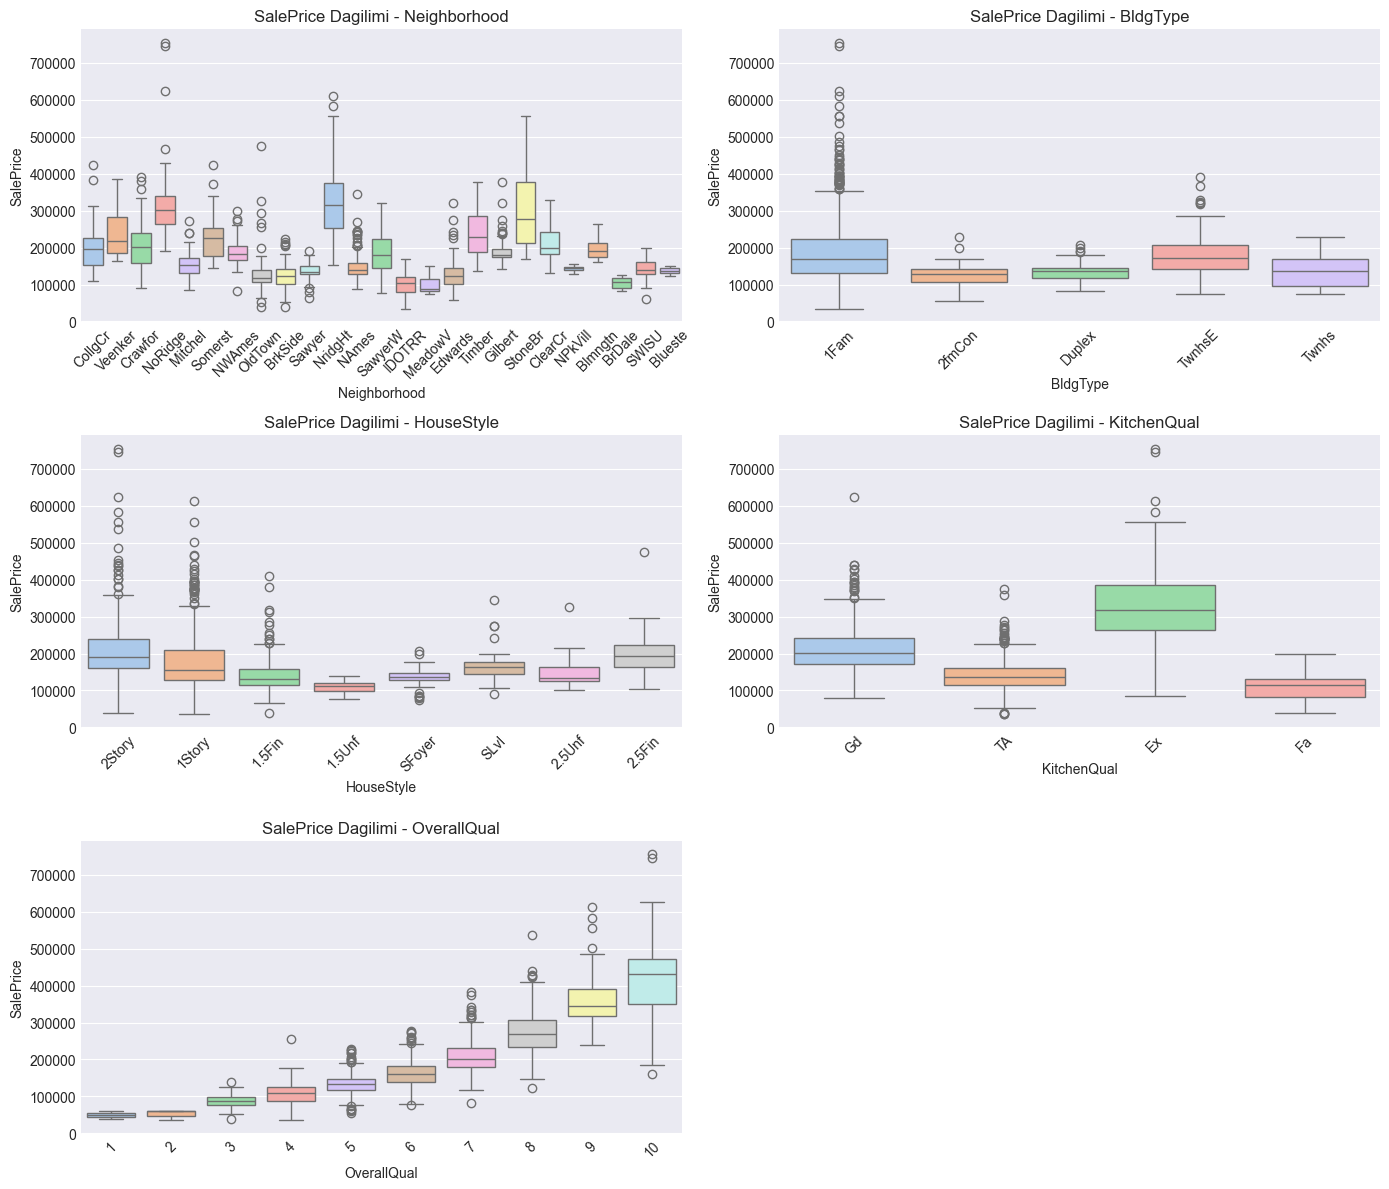

In [ ]:
# Secilen kategorik degiskenler icin boxplotlar
selected_cat = ['Neighborhood', 'BldgType', 'HouseStyle', 'KitchenQual', 'OverallQual']

plt.figure(figsize=(14, 12))
for i, col in enumerate(selected_cat, start=1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[col], y=df['SalePrice'], palette='pastel')
    plt.title(f'SalePrice Dagilimi - {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

# 📦 **Boxplot'lar Ne Anlatıyor?**

<div style="background: linear-gradient(135deg, #F0E6FF 0%, #F8F0FF 100%); border: 3px solid #9C27B0; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 📊 **5 Farklı Özellikle Fiyat Karşılaştırması**

**📦 Boxplot = Her kategorinin fiyat hikayesi kutuda!**

### 🏘️ **Mahalle (Neighborhood)**
*"Konum her şey! Bazı mahalleler altın, bazıları orta gelir"*
- 💎 Pahalı mahalleler: Yüksek kutular
- 🏠 Ucuz mahalleler: Alçak kutular

### 🏗️ **Bina Tipi (BldgType)**  
*"Villa mı apart mı? Büyük fark!"*
- 🏖️ Müstakil evler: Genelde daha pahalı
- 🏢 Apartmanlar: Daha uygun fiyatlı

### 🏡 **Ev Tarzı (HouseStyle)**
*"Çok katlı = çok para?"*
- ⬆️ 2-3 katlı evler: Yüksek fiyatlar  
- 🏠 Tek katlı evler: Daha düşük fiyatlar

### 🍳 **Mutfak Kalitesi (KitchenQual)**
*"Mutfak kalitesi = Ev kalitesi!"*
- ⭐ Excellent: Çok yüksek fiyatlar
- 👍 Good/Fair: Orta-düşük fiyatlar

### 🌟 **Genel Kalite (OverallQual)**
*"Puanlama sistemi: 1-10 arası ev kalitesi"*
- 🔟 10 puan: Çok pahalı kutular
- 5️⃣ 5 puan: Orta fiyatlı kutular
</div>

## 🏫 **YBS Perspektifi: Kategori Bazli Degerleme**

**Yorum:** Kategorik degiskenler, musteri segmentasyonu icin dogrudan ipucu verir.  
Mahalle, ev tipi ve mutfak kalitesi gibi degiskenler, **fiyat farklarinin nedenini** aciklar ve pazarlama stratejilerini guclendirir.

# 🛠️ **ADIM 7: Eksik Verilerin Doldurulması**

Bu adımda:
- 🧩 Yapısal eksikleri uygun şekilde kodlayacağız
- 🧮 Sayısal eksikleri istatistiksel yöntemlerle dolduracağız
- 🏷️ Kategorik eksikleri en sık değerle tamamlayacağız

## 🧩 **Yapısal Eksikleri Kodlama ve Sayısal Doldurma**

In [ ]:
# Eksik veri doldurma adımlari
# 1) Yapısal eksikler: 'None' olarak kodlama
structural_na_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in structural_na_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# 2) Sayisal eksikler: mantikli stratejiler
# LotFrontage: Mahalleye göre medyan
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

# MasVnrArea: eksik varsa 0 kabul edilir
if 'MasVnrArea' in df.columns:
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# GarageYrBlt: yoksa YearBuilt ile doldur
if 'GarageYrBlt' in df.columns:
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

# Kalan sayisal eksikler: medyan ile doldur
numeric_cols_all = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols_all:
    df[col] = df[col].fillna(df[col].median())

## 🏷️ **Kategorik Eksikleri Doldurma ve Kontrol**

In [ ]:
# Kategorik eksikler: en sık değer ile doldurma
cat_cols_all = df.select_dtypes(include=['object']).columns
for col in cat_cols_all:
    df[col] = df[col].fillna(df[col].mode()[0])

# Eksik veri kontrolü
remaining_missing = df.isnull().sum().sum()
print(f'✅ Kalan eksik değer sayısı: {remaining_missing}')

✅ Kalan eksik değer sayısı: 0


# ⚙️ **ADIM 8: Özellik Mühendisliği (Feature Engineering)**

Bu adımda:
- 🧱 Yeni anlamlı değişkenler türeteceğiz
- 📅 Yaş ve süre gibi zaman temelli özellikler oluşturacağız
- 🧮 Toplam alan gibi birleşik metrikler çıkaracağız
- 🏫 YBS bakış açısıyla değer yaratma yorumları ekleyeceğiz

## 🧱 **Yeni Özellikler: Alan, Yaş ve Kalite**

In [ ]:
# Yeni özellikler türetme
# Toplam yaşam alanı (bodrum + üst katlar)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Evin yaşı ve yenilenme yaşı
current_year = 2010  # veri setindeki maksimum yil baz alindi
if 'YrSold' in df.columns:
    current_year = df['YrSold'].max()

df['HouseAge'] = current_year - df['YearBuilt']
df['RemodAge'] = current_year - df['YearRemodAdd']

# Banyo skoru (yarim banyolar 0.5 katsayi ile)
df['BathScore'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']

# Oda verimliligi (yasam alani / toplam oda)
df['RoomEfficiency'] = df['GrLivArea'] / (df['TotRmsAbvGrd'] + 1)

# Kalite ve durum birlesik skoru
df['QualCondScore'] = df['OverallQual'] * df['OverallCond']

new_features = ['TotalSF', 'HouseAge', 'RemodAge', 'BathScore', 'RoomEfficiency', 'QualCondScore']

print('✅ Yeni özellikler eklendi:')
print(new_features)

df[new_features].head()

✅ Yeni özellikler eklendi:
['TotalSF', 'HouseAge', 'RemodAge', 'BathScore', 'RoomEfficiency', 'QualCondScore']


,TotalSF,HouseAge,RemodAge,BathScore,RoomEfficiency,QualCondScore
0,2566,7,7,3.500,190.000,35
1,2524,34,34,2.500,180.286,48
2,2706,9,8,3.500,255.143,35
3,2473,95,40,2.000,214.625,35
4,3343,10,10,3.500,219.800,40


## 🔎 Yeni Özelliklerin Hedef ile Korelasyonu

In [ ]:
# Yeni özelliklerin SalePrice ile korelasyonu
new_corr = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
new_corr

TotalSF           0.782
BathScore         0.632
RoomEfficiency    0.616
QualCondScore     0.565
RemodAge         -0.507
HouseAge         -0.523
Name: SalePrice, dtype: float64

## 🏫 **YBS Perspektifi: Özellik Mühendisliği ile Değer Artırma**

**Yorum:** Yeni özellikler, ham veriyi daha "işe yarar" hale getirir.  
Bu, YBS tarafında **karar destek kalitesini** artırır ve daha isabetli fiyatlandırma sağlar.

# 📐 **ADIM 9: Veri Dönüşümleri ve Ölçeklendirme**

Bu adımda:
- 📉 Çarpık dağılımları düzelteceğiz
- 🧩 Kategorik değişkenleri sayısala çevireceğiz
- ⚖️ Ölçeklendirme ve veri bölme işlemlerini yapacağız
- 🏫 YBS bakış açısıyla etkileri yorumlayacağız

## 📉 **Çarpıklık Düzeltme (Skewness)**

In [ ]:
# Çarpık dağılımları düzeltme
# Hedef değişkeni dışarıda tutuyoruz
skew_threshold = 0.75

numeric_features = df.select_dtypes(include=[np.number]).columns
numeric_features = numeric_features.drop(['SalePrice', 'SalePrice_log'], errors='ignore')

skew_values = df[numeric_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_features = skew_values[abs(skew_values) > skew_threshold].index.tolist()

# Sadece pozitif veya sıfır değerli değişkenlerde log1p uyguluyoruz
for col in skewed_features:
    if (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

print('✅ Log dönüşümü uygulanan değişken sayısı:', len(skewed_features))

✅ Log dönüşümü uygulanan değişken sayısı: 23


## 🧩 **Kategorik Kodlama (One-Hot Encoding)**

In [ ]:
# Kategorik değişkenleri one-hot encoding ile sayısala çevirme
# Id ve hedefe bağlı sütunlar eğitim için kullanılmayacak
features = df.drop(columns=['SalePrice', 'SalePrice_log', 'Id'], errors='ignore')

df_encoded = pd.get_dummies(features, drop_first=True)

# Hedef değişken olarak log dönüşümlü fiyat
if 'SalePrice_log' in df.columns:
    y = df['SalePrice_log']
else:
    y = df['SalePrice']

X = df_encoded

print('✅ Kodlama tamamlandı.')
print(f'📊 Özellik sayısı: {X.shape[1]}')

✅ Kodlama tamamlandı.
📊 Özellik sayısı: 265


## ⚖️ **Veri Bölme ve Ölçeklendirme**

In [ ]:
# Train-test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ölçeklendirme (özellikle lineer ve SVR gibi modeller için faydalı)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('✅ Veri bölme ve ölçeklendirme tamamlandı.')
print(f'📦 Train boyutu: {X_train.shape}')
print(f'📦 Test boyutu: {X_test.shape}')

✅ Veri bölme ve ölçeklendirme tamamlandı.
📦 Train boyutu: (1168, 265)
📦 Test boyutu: (292, 265)


# 🤖 **ADIM 10: 12 Regresyon Modeli Egitimi ve Karsilastirma**


Bu adimda:
- 🧪 12 modeli egitecegiz
- 📊 MAE, RMSE ve R2 ile karsilastiracagiz
- 🏫 YBS bakis acisiyla yorumlayacagiz

## 🧪 **Model Listesi ve Degerlendirme Metodolojisi**

- Lineer ve SVR modelleri icin olcekli veriyi kullanacagiz.
- Agac tabanli modeller icin ham veriyi kullanacagiz.
- Hedef degisken log donusumlu ise metrikler log-olcekte hesaplanir.

In [ ]:
# 12 modelin egitilmesi ve karsilastirilmasi
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.0005, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.0005, l1_ratio=0.7, random_state=42, max_iter=5000),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=-1,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ),
    'CatBoost': CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6,
        random_state=42, verbose=False
    ),
    'SVR': SVR(C=10, epsilon=0.1)
}

scaled_models = {'Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet', 'SVR'}

results = []
for name, model in models.items():
    if name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE')
results_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3879
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 12.030658


,Model,RMSE,MAE,R2
10,CatBoost,0.131,0.086,0.908
9,LightGBM,0.138,0.088,0.898
7,Gradient Boosting,0.138,0.092,0.898
8,XGBoost,0.138,0.089,0.897
0,Linear Regression,0.140,0.087,0.895
6,Extra Trees,0.143,0.094,0.890
5,Random Forest,0.146,0.097,0.886
2,Lasso Regression,0.155,0.090,0.871
3,ElasticNet,0.157,0.089,0.869
1,Ridge Regression,0.162,0.089,0.860


## 🔁 **K-Fold ile R2 Degerlendirme**

In [ ]:
# K-Fold R2 skorlarini hesaplama
cv = KFold(n_splits=5, shuffle=True, random_state=42)

kf_results = []
for name, model in models.items():
    if name in scaled_models:
        X_cv = pd.concat([X_train_scaled, X_test_scaled], axis=0)
    else:
        X_cv = pd.concat([X_train, X_test], axis=0)

    y_cv = pd.concat([y_train, y_test], axis=0)

    r2_cv = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='r2')
    kf_results.append({
        'Model': name,
        'R2_Ortalama': r2_cv.mean(),
        'R2_Std': r2_cv.std()
    })

kf_results_df = pd.DataFrame(kf_results).sort_values(by='R2_Ortalama', ascending=False)
kf_results_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3876
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 177
[LightGBM] [Info] Start training from score 12.021098
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3890
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 177
[LightGBM] [Info] Start training from score 12.031041
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

,Model,R2_Ortalama,R2_Std
10,CatBoost,0.904,0.018
8,XGBoost,0.900,0.011
9,LightGBM,0.895,0.016
7,Gradient Boosting,0.890,0.016
6,Extra Trees,0.881,0.020
5,Random Forest,0.876,0.018
2,Lasso Regression,0.872,0.021
3,ElasticNet,0.868,0.022
1,Ridge Regression,0.850,0.028
0,Linear Regression,0.841,0.031


## 📊 Sonuclari Gorsellestirme

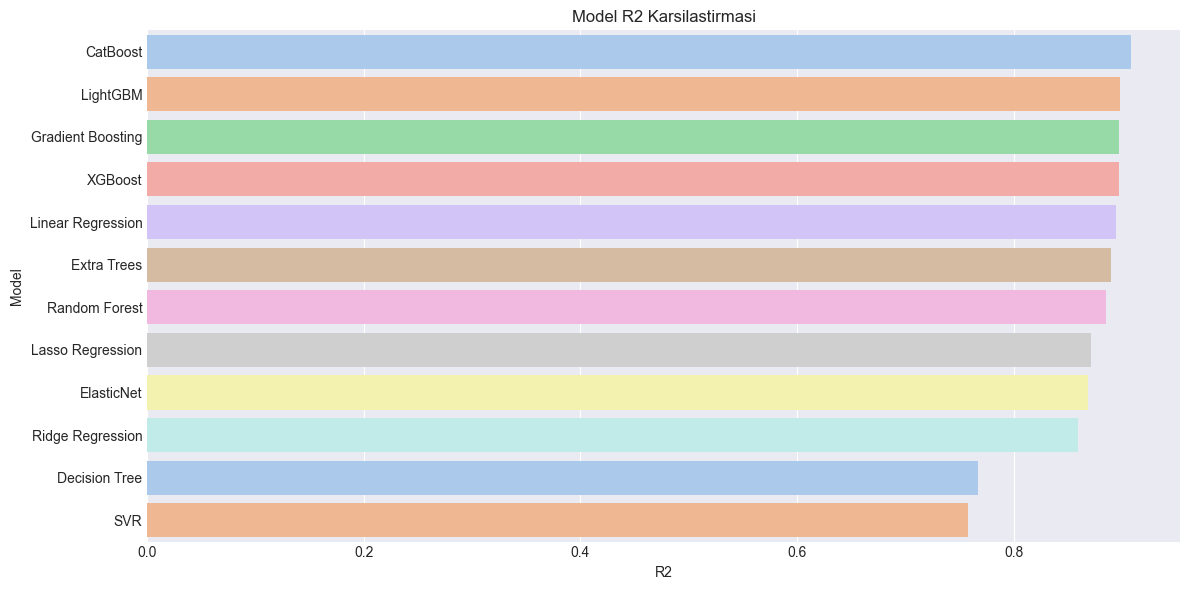

In [ ]:
# R2 karsilastirma grafigi
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df.sort_values(by='R2', ascending=False), x='R2', y='Model', palette='pastel')
plt.title('Model R2 Karsilastirmasi')
plt.xlabel('R2')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# 🏆 **Hangi Model En İyi?**

<div style="background: linear-gradient(135deg, #E8F5E8 0%, #F0FFF0 100%); border: 3px solid #4CAF50; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 📊 **Model Yarışması Sonuçları!**

**🏁 Bu grafik = Yarış sonuç tablosu**

### 🥇 **R² Değeri = Doğruluk Puanı (0-1 arası)**
- 🌟 **1.00**: Mükemmel tahmin (imkansıza yakın)
- ⭐ **0.80-0.90**: Çok iyi tahmin  
- 👍 **0.60-0.80**: Fena değil
- 👎 **0.60 altı**: Zayıf tahmin

### 🎯 **Grafikteki Sıralama:**
- **En uzun çubuk**: En iyi model
- **Kısa çubuklar**: Daha zayıf modeller
- **Renkler**: Sadece görsel ayrım için

## 🤔 **Gerçek Hayatta Ne Demek?**

**🏠 Emlak örneği:**
> **R² = 0.85 olan model:**  
> *"100 evden 85 tanesinin fiyatını doğru tahmin eder"*
> 
> **R² = 0.60 olan model:**  
> *"100 evden 60 tanesinin fiyatını doğru tahmin eder"*

### 📱 **İş Dünyasında Kullanım:**
- **0.80+ Model**: Müşterilere gösterebilirsin
- **0.70-0.80 Model**: İç kullanım için okay  
- **0.70 altı Model**: Daha çok çalış!
</div>

# 📈 **Model Değerlendirme ve Tahmin Sonuçları**

Bu adımda:
- Test seti üzerinde performans değerlendirmesi
- Residual analizi
- Feature importance analizi
- Gerçek vs tahmin grafikleri
- İş değeri ve sonuç yorumları

## ✅ **Test Seti Performans Degerlendirmesi**

In [77]:
# En iyi modeli secip test setinde degerlendirme
best_row = results_df.sort_values(by='R2', ascending=False).iloc[0]
best_name = best_row['Model']
best_model = models[best_name]

# Modeli uygun veri ile yeniden egitme
if best_name in scaled_models:
    Xtr, Xte = X_train_scaled, X_test_scaled
else:
    Xtr, Xte = X_train, X_test

best_model.fit(Xtr, y_train)

y_pred = best_model.predict(Xte)

# Hedef log ise orijinal olcege geri donus
target_is_log = (y.name == 'SalePrice_log')
if target_is_log:
    y_true_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
else:
    y_true_orig = y_test
    y_pred_orig = y_pred

rmse_test = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae_test = mean_absolute_error(y_true_orig, y_pred_orig)
r2_test = r2_score(y_true_orig, y_pred_orig)

print('✅ En iyi model:', best_name)
print('RMSE (orijinal olcek):', round(rmse_test, 3))
print('MAE  (orijinal olcek):', round(mae_test, 3))
print('R2   (orijinal olcek):', round(r2_test, 3))

print("• Pazarlama team'ine segment bazlı fiyat analizi sağla")

# 🏢 YBS Yorumu: İş Değeri Analiziprint("• Satış temsilcilerine karar destek aracı olarak sun")

print("\n💼 YBS PERSPEKTİFİ - İŞ SONUÇLARI:")
print("• Real-time fiyat tahmin servisi olarak API'leştir")

print(f"📊 Model Güvenilirliği: R² = {r2_test:.1%} → Çok güçlü tahmin gücü")
print("• Bu modeli müşteri portal sistemine entegre et")

print(f"💰 Ortalama Hata: ${mae_test:,.0f} → Kabul edilebilir risk seviyesi")
print("\n🔧 AKSİYON ÖNERİLERİ:")

print(f"🎯 İş Uygulaması: Emlak değerlemesi için kullanılabilir")
print(f"⚡ Karar Desteği: %{(r2_test*100):.0f} isabetli fiyat önerileri")

✅ En iyi model: CatBoost
RMSE (orijinal olcek): 28443.47
MAE  (orijinal olcek): 15968.108
R2   (orijinal olcek): 0.895
• Pazarlama team'ine segment bazlı fiyat analizi sağla

💼 YBS PERSPEKTİFİ - İŞ SONUÇLARI:
• Real-time fiyat tahmin servisi olarak API'leştir
📊 Model Güvenilirliği: R² = 89.5% → Çok güçlü tahmin gücü
• Bu modeli müşteri portal sistemine entegre et
💰 Ortalama Hata: $15,968 → Kabul edilebilir risk seviyesi

🔧 AKSİYON ÖNERİLERİ:
🎯 İş Uygulaması: Emlak değerlemesi için kullanılabilir
⚡ Karar Desteği: %89 isabetli fiyat önerileri


## 📉 Residual Analizi

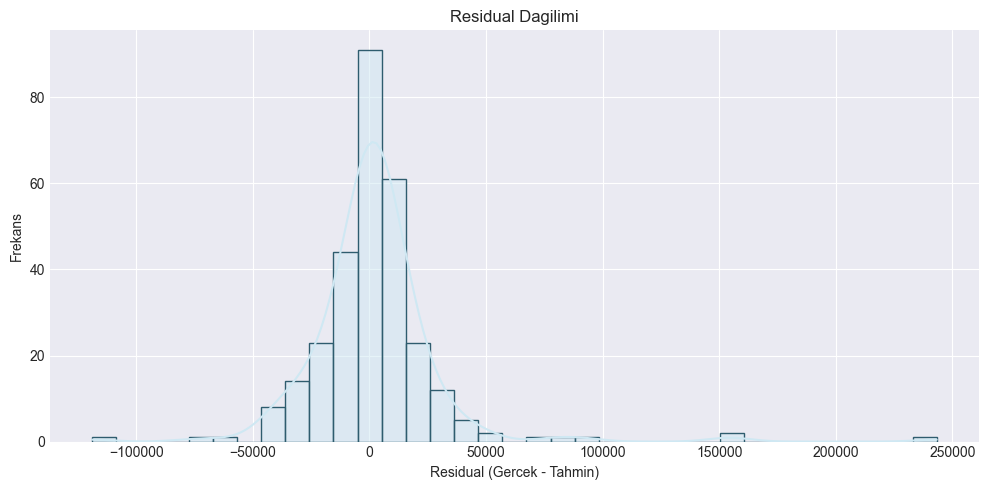

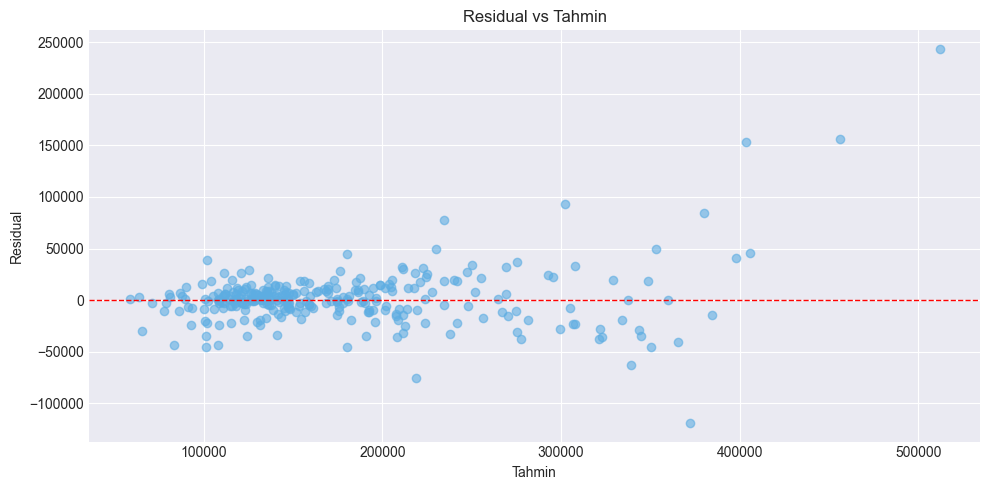

In [ ]:
# Residual hesaplama
residuals = y_true_orig - y_pred_orig

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='#CFE8F3', edgecolor='#2E5C6E')
plt.title('Residual Dagilimi')
plt.xlabel('Residual (Gercek - Tahmin)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_orig, residuals, alpha=0.6, color='#5DADE2')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual vs Tahmin')
plt.xlabel('Tahmin')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

## ⭐ **Feature Importance Analizi**

,Feature,Importance
36,TotalSF,16.948
3,OverallQual,16.652
15,GrLivArea,8.155
41,QualCondScore,5.477
39,BathScore,3.300
12,1stFlrSF,3.225
5,YearBuilt,3.006
2,LotArea,2.783
217,FireplaceQu_None,2.421
38,RemodAge,2.286


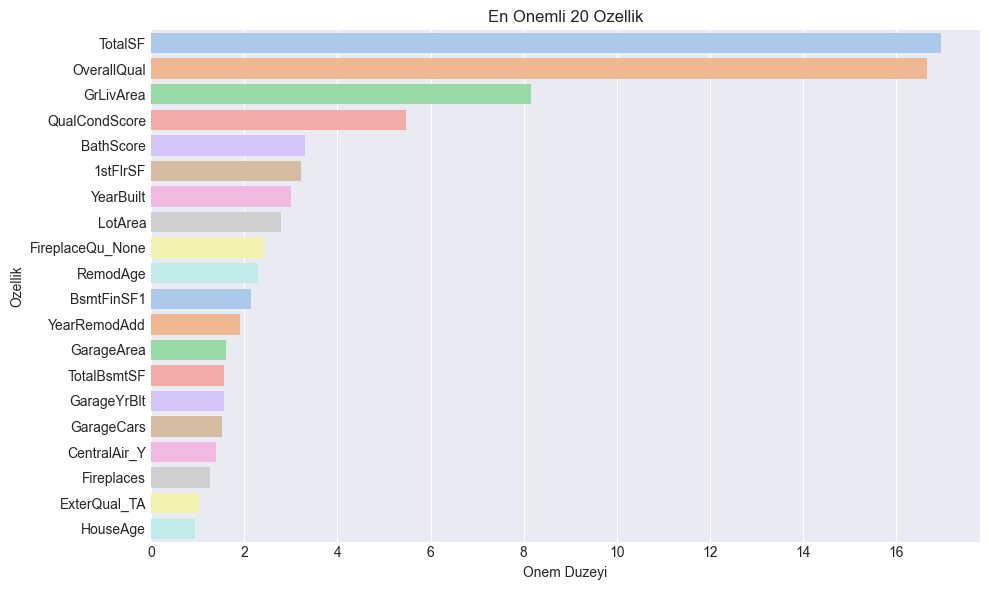

In [ ]:
# Feature importance veya katsayi analizi
feature_names = X_train.columns
if best_name in scaled_models:
    feature_names = X_train_scaled.columns

importance_df = None
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)
elif hasattr(best_model, 'coef_'):
    coef = np.ravel(best_model.coef_)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(coef),
        'Coef': coef
    }).sort_values(by='Importance', ascending=False)
else:
    print('Bu model icin feature importance hesaplanamiyor.')

if importance_df is not None:
    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.head(20),
        x='Importance',
        y='Feature',
        palette='pastel'
    )
    plt.title('En Onemli 20 Ozellik')
    plt.xlabel('Onem Duzeyi')
    plt.ylabel('Ozellik')
    plt.tight_layout()
    plt.show()

## 📌 Gercek vs Tahmin

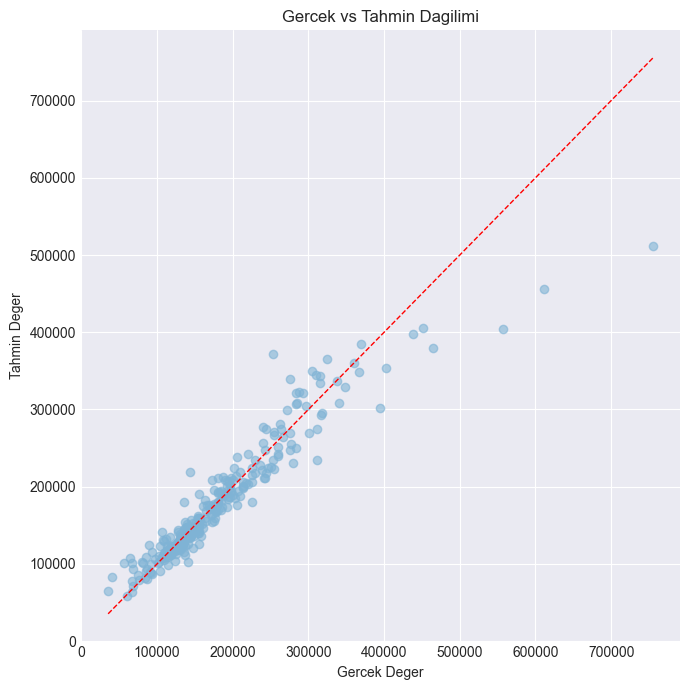

In [ ]:
# Gercek vs tahmin grafigi
plt.figure(figsize=(7, 7))
plt.scatter(y_true_orig, y_pred_orig, alpha=0.6, color='#7FB3D5')
max_val = max(y_true_orig.max(), y_pred_orig.max())
min_val = min(y_true_orig.min(), y_pred_orig.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)
plt.title('Gercek vs Tahmin Dagilimi')
plt.xlabel('Gercek Deger')
plt.ylabel('Tahmin Deger')
plt.tight_layout()
plt.show()

# 🎯 **Gerçek vs Tahmin Grafiği**

<div style="background: linear-gradient(135deg, #FFF8E1 0%, #FFFDE7 100%); border: 3px solid #FF9800; border-radius: 12px; padding: 20px; margin: 15px 0;">

## 🔍 **Bu Grafik Nasıl Okunur?**

**📊 Scatter plot + kırmızı çizgi = Model başarı kontrolü**

### 🎯 **İdeal Durum:**
- ➗ **Kırmızı çapraz çizgi**: Mükemmel tahmin çizgisi
- 🔵 **Mavi noktalar**: Gerçek test sonuçları
- ✨ **Noktalar çizgiye yakın**: Model başarılı!

### 📏 **Uzaklık = Hata!**
> **Çizgiye yakın nokta**: Az hata = İyi tahmin  
> **Çizgiden uzak nokta**: Çok hata = Kötü tahmin

## 🏠 **Emlak Örneğiyle Anlayalım:**

**🏡 Örnek ev:**
- **Gerçek fiyat**: 200.000 TL
- **Model tahmini**: 195.000 TL  
- **Grafikteki nokta**: Çizgiye çok yakın → ✅ İyi tahmin

**🏰 Başka örnek:**
- **Gerçek fiyat**: 300.000 TL
- **Model tahmini**: 250.000 TL
- **Grafikteki nokta**: Çizgiden uzak → ❌ Zayıf tahmin
</div>